# Setting up an RL Environment with Gymnasium

## Learning Objectives

By completing this notebook, you will:
- install and set up Gymnasium
- understand environment spaces, observations, and actions
- interact with environments using `reset()` and `step()`
- explore different classic control and tabular environments
- prepare for later RL notebooks that use the same API

## Prerequisites

- Python 3.8+ installed
- pip package manager
- basic Python knowledge
- basic RL concepts: agent, environment, reward

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- setting up an RL environment with Gymnasium and Python tools for RL

## Introduction

**Gymnasium** is the maintained successor to OpenAI Gym. It provides a standard
interface for reinforcement learning environments, making it easier to test the
same algorithm across different problems.

## Lesson Brief

This lesson introduces the environment interface students will keep using throughout the course.

The goal is not to train an agent yet, but to understand how an RL environment is created, reset, stepped through, and inspected.

Why this matters: students need to know how the environment talks to the agent before they can understand any learning loop.

This notebook prepares them for practical work in the notebooks that follow.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Environment: the simulator.
- Observation: what the agent sees.
- Action space: allowed actions.
- Episode: one full run.

### Quick Check
- What comes back from reset and step?
- Why inspect spaces before training?
- How do you know an episode ended?

### Common Mistakes
- Ignoring the action space.
- Confusing observation with reward.
- Treating termination and truncation as identical.


## What you should learn from this notebook

By the end of this notebook, you should be able to:

- install and import Gymnasium correctly
- create an environment with `gym.make(...)`
- use `reset()` and `step(...)`
- understand the meaning of `observation`, `reward`, `terminated`, and `truncated`
- inspect action and observation spaces before training any agent


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install "gymnasium[classic_control]" matplotlib numpy -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print(f"Gymnasium version: {gym.__version__}")
print("\nSetting up an RL Environment with Gymnasium")
print("=" * 60)

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!
Gymnasium version: 1.1.1

Setting up an RL Environment with Gymnasium


## Part 1: Installing and Setting Up Gymnasium


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("=" * 60)
print("Part 1: Installing and Setting Up Gymnasium")
print("=" * 60)

print("\n1. Installation:")
print(" pip install gymnasium[classic_control]")

print("\n2. Import gymnasium:")
print(" import gymnasium as gym")

print("\n3. List some registered environment ids:")
print(" from gymnasium.envs.registration import registry")
print(" sorted(k for k in registry.keys())[:20]  # sample")

# List some popular environments
print("\n3. Popular Gymnasium Environments:")
popular_envs = [
 "CartPole-v1", "FrozenLake-v1",
 "MountainCar-v0",
 "Acrobot-v1",
 "LunarLander-v2"
]
for env_name in popular_envs:
 print(f" - {env_name}")

print("\n✅ Gym setup complete!")

Part 1: Installing and Setting Up Gymnasium

1. Installation:
 pip install gymnasium[classic_control]

2. Import gymnasium:
 import gymnasium as gym

3. List some registered environment ids:
 from gymnasium.envs.registration import registry
 sorted(k for k in registry.keys())[:20]  # sample

3. Popular Gymnasium Environments:
 - CartPole-v1
 - FrozenLake-v1
 - MountainCar-v0
 - Acrobot-v1
 - LunarLander-v2

✅ Gym setup complete!


## Part 2: Understanding Observation and Action Spaces

Before training anything, inspect what the environment gives the agent and what
choices the agent is allowed to make.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 2: Understanding Observation and Action Spaces")
print("=" * 60)

env = gym.make("CartPole-v1")
obs, info = env.reset()

print("Environment:", env.spec.id)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial observation:", obs)
print("Info dictionary:", info)

print("\nKey idea:")
print("- Observation space describes what the agent can observe.")
print("- Action space describes what the agent is allowed to do.")

env.close()


Part 2: Understanding Observation and Action Spaces
Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.04290244 -0.04384312  0.01232446  0.0341115 ]
Info dictionary: {}

Key idea:
- Observation space describes what the agent can observe.
- Action space describes what the agent is allowed to do.


## Part 3: Interacting with an Environment

The Gymnasium loop always follows the same pattern:

1. `env.reset()` to start a new episode
2. choose an action
3. `env.step(action)` to move the environment forward
4. check `terminated` or `truncated`
5. repeat until the episode ends

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 3: Interacting with Gym Environments")
print("=" * 60)

env = gym.make("FrozenLake-v1", is_slippery=False)
obs, info = env.reset(seed=42)

print("Starting observation:", obs)

for step_idx in range(5):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    print(
        f"Step {step_idx + 1}: action={action}, next_obs={next_obs}, "
        f"reward={reward}, terminated={terminated}, truncated={truncated}"
    )
    obs = next_obs
    if terminated or truncated:
        print("Episode finished, so we would call reset() before continuing.")
        break

env.close()

print("\nCheckpoint:")
print("- terminated=True means the task ended naturally (goal, failure, etc.).")
print("- truncated=True means the episode was cut off by a limit, such as max steps.")


Part 3: Interacting with Gym Environments
Starting observation: 0
Step 1: action=3, next_obs=0, reward=0.0, terminated=False, truncated=False
Step 2: action=0, next_obs=0, reward=0.0, terminated=False, truncated=False
Step 3: action=3, next_obs=0, reward=0.0, terminated=False, truncated=False
Step 4: action=1, next_obs=4, reward=0.0, terminated=False, truncated=False
Step 5: action=1, next_obs=8, reward=0.0, terminated=False, truncated=False

Checkpoint:
- terminated=True means the task ended naturally (goal, failure, etc.).
- truncated=True means the episode was cut off by a limit, such as max steps.


## Part 4: Comparing Different Gym Environments

Different environments can have very different observation and action spaces.

That is why checking the environment API comes *before* choosing an algorithm.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 4: Exploring Different Gym Environments")
print("=" * 60)

environment_names = [
    "CartPole-v1",
    "FrozenLake-v1",
    "MountainCar-v0",
]

for env_name in environment_names:
    env = gym.make(env_name)
    obs, info = env.reset(seed=42)
    print(f"\nEnvironment: {env_name}")
    print(" Observation space:", env.observation_space)
    print(" Action space:", env.action_space)
    print(" Initial observation:", obs)
    env.close()

print("\nTakeaway:")
print("The environment interface stays similar, but the state representation and")
print("action choices change from problem to problem.")


Part 4: Exploring Different Gym Environments

Environment: CartPole-v1
 Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
 Action space: Discrete(2)
 Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Environment: FrozenLake-v1
 Observation space: Discrete(16)
 Action space: Discrete(4)
 Initial observation: 0

Environment: MountainCar-v0
 Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
 Action space: Discrete(3)
 Initial observation: [-0.4452088  0.       ]

Takeaway:
The environment interface stays similar, but the state representation and
action choices change from problem to problem.


## Why Gymnasium matters in real RL work

Gymnasium gives you a standard environment interface.

That means you can:
- swap environments without rewriting your whole training loop
- compare algorithms more fairly
- focus on RL logic instead of custom environment plumbing

In later units, you will use this same interface for tabular RL and deep RL.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


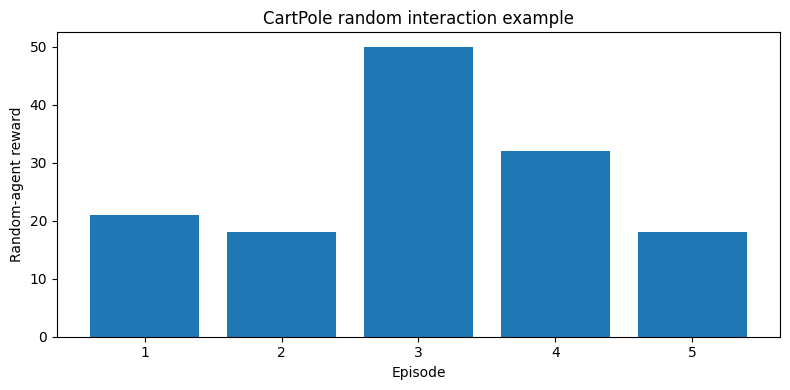

Random episode rewards: [21.0, 18.0, 50.0, 32.0, 18.0]

Important lesson:
Gym setup is not the same as training an agent.
This notebook teaches environment interaction only.


In [6]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def run_random_episode(env_name, max_steps=25, seed=42):
    env = gym.make(env_name)
    obs, info = env.reset(seed=seed)
    total_reward = 0.0

    for _ in range(max_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    env.close()
    return total_reward


cartpole_rewards = [run_random_episode("CartPole-v1", max_steps=50, seed=42 + i) for i in range(5)]

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cartpole_rewards)
plt.xlabel("Episode")
plt.ylabel("Random-agent reward")
plt.title("CartPole random interaction example")
plt.tight_layout()
plt.show()

print("Random episode rewards:", cartpole_rewards)
print("\nImportant lesson:")
print("Gym setup is not the same as training an agent.")
print("This notebook teaches environment interaction only.")

## Summary

You now know how to:

- install and import Gymnasium
- inspect observation and action spaces
- create an environment with `gym.make(...)`
- start an episode with `reset()`
- move the environment forward with `step(action)`
- interpret `reward`, `terminated`, and `truncated`
- close the environment cleanly

### Common mistake to avoid

Do not confuse **environment interaction** with **learning**.

In this notebook, the agent mostly used random actions. In later notebooks, you will
replace that with real decision-making algorithms.

### Next step

Move to `05_exploration_strategies_epsilon_greedy.ipynb` to understand how an agent
balances trying new actions with using what it already knows.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


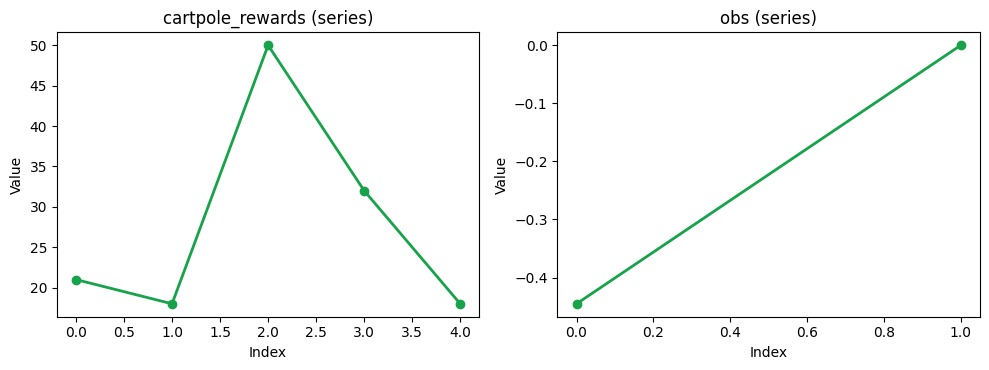

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Gymnasium gives students a standard way to reset an environment, take actions, observe rewards, and run RL experiments safely.

**If students remember one idea:** Before training any agent, students should know how to inspect the environment loop and understand what each step returns.

**Quick check before moving on:**
- Can you explain what comes back from reset() and step()?
- Can you describe why environment interaction must be clear before algorithm design begins?

**Bridge to the next step:** With the environment loop in place, the next lessons can focus on exploration and decision-making behavior.
